In [1]:
# Setup
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import math

# GPU memory config
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    tf.config.optimizer.set_jit(True)  # Enable XLA for potential performance improvement

print(f"TensorFlow version: {tf.__version__}")
print("GPU Available:", tf.config.list_physical_devices('GPU'))

np.random.seed(42)
tf.random.set_seed(42)

# Constants
LATENT_DIM = 64
KL_WEIGHT = 1.0
BATCH_SIZE = 512
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001
CLIPNORM = 2.0      # Higher for more stable training, lower for more aggressive updates (0.5-10 is common)
EPOCHS = 100

BASE_FILTERS = 16
NUM_LAYERS = 4
BOTTLENECK_DIM = 4

IMAGE_SIZE_X = 32
IMAGE_SIZE_Y = 32
CHANNELS = 3        # 1 for grayscale, 3 for RGB

STRIDE = 2          # Stride for downsampling layers until bottleneck is reached

NUM_DOWNSAMP = int(math.log2(IMAGE_SIZE_X // BOTTLENECK_DIM))   # Stops downsampling when feature map size reaches BOTTLENECK_DIM

2026-05-01 12:37:43.514608: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-01 12:37:44.338893: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-01 12:37:46.748978: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Sampling Layer
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = keras.random.normal(shape=keras.ops.shape(z_mean), dtype=z_mean.dtype)
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon

# Encoder
def build_encoder(latent_dim=LATENT_DIM):
    inputs = keras.Input(shape=(IMAGE_SIZE_X, IMAGE_SIZE_Y, CHANNELS))
   
    x = inputs
    for i in range(NUM_LAYERS):
        filters = BASE_FILTERS * (2 ** i)

        stride = STRIDE if i < NUM_DOWNSAMP else 1     # Stops downsampling when feature map size reaches BOTTLENECK_DIM

        x = layers.Conv2D(filters, 3, strides=stride, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
    
    x = layers.Flatten()(x)
    x = layers.Dropout(0.2)(x)
    
    z_mean    = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
    z         = Sampling()([z_mean, z_log_var])
    
    return keras.Model(inputs, [z_mean, z_log_var, z], name='encoder')

# Decoder
def build_decoder(latent_dim=LATENT_DIM):
    inputs = keras.Input(shape=(latent_dim,))

    final_filters = BASE_FILTERS * (2 ** (NUM_LAYERS - 1))
    
    x = layers.Dense(BOTTLENECK_DIM * BOTTLENECK_DIM * final_filters, activation='relu')(inputs)
    x = layers.Reshape((BOTTLENECK_DIM, BOTTLENECK_DIM, final_filters))(x)

    for i in range(NUM_LAYERS - 1, -1, -1):
        filters = BASE_FILTERS * (2 ** i)

        stride = STRIDE if i < NUM_DOWNSAMP else 1     # Stops upsampling above the original image size

        x = layers.Conv2DTranspose(filters, 3, strides=stride, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
    
    outputs = layers.Conv2D(CHANNELS, 3, padding='same', activation='tanh', dtype='float32')(x)
    
    return keras.Model(inputs, outputs, name='decoder')

# VAE
class VAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight, **kwargs):
        super().__init__(**kwargs)
        self.encoder   = encoder
        self.decoder   = decoder
        self.kl_weight = kl_weight

    def call(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        return self.decoder(z)

    def _compute_losses(self, x, reconstruction, z_mean, z_log_var):
        recon_loss = recon_loss = tf.reduce_mean(
        tf.reduce_sum(tf.square(x - reconstruction), axis=[1, 2, 3])
        )
        kl_loss = -0.5 * tf.reduce_mean(
            z_log_var - tf.square(z_mean) - tf.exp(z_log_var) + 1
        )
        total_loss = recon_loss + self.kl_weight * kl_loss
        return {"loss": total_loss, "recon_loss": recon_loss, "kl_loss": kl_loss}

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x, training=True)
            reconstruction       = self.decoder(z, training=True)
            losses               = self._compute_losses(x, reconstruction, z_mean, z_log_var)
        grads = tape.gradient(losses["loss"], self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return losses

    def test_step(self, data):
        x, _ = data
        z_mean, z_log_var, z = self.encoder(x, training=False)
        reconstruction       = self.decoder(z, training=False)
        return self._compute_losses(x, reconstruction, z_mean, z_log_var)

encoder = build_encoder(latent_dim=LATENT_DIM)
decoder = build_decoder(latent_dim=LATENT_DIM)
vae     = VAE(encoder, decoder, kl_weight=KL_WEIGHT, name='vae')
vae.compile(optimizer=keras.optimizers.AdamW(
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    clipnorm=CLIPNORM
))
print("VAE built successfully")

I0000 00:00:1777635469.224388 1274351 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


VAE built successfully


In [3]:
# Load CIFAR-10
(x_train, _), (x_test, _) = keras.datasets.cifar10.load_data()

x_train = (x_train.astype('float32') / 127.5) - 1.0
x_test  = (x_test.astype('float32')  / 127.5) - 1.0

print(f"Training data: {x_train.shape}")
print(f"Test data:     {x_test.shape}")

# tf.data pipeline
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, x_train))
train_dataset = train_dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset   = tf.data.Dataset.from_tensor_slices((x_test, x_test))
val_dataset   = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Callbacks

'''
checkpoint = keras.callbacks.ModelCheckpoint(
    'checkpoint.model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
'''

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', min_delta=0.1, patience=7, verbose=1, restore_best_weights=True
)
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=1e-5
)

history = vae.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[early_stopping, lr_scheduler]
)

/home/username/tf-env/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data: (50000, 32, 32, 3)
Test data:     (10000, 32, 32, 3)


I0000 00:00:1777635484.797189 1274351 cuda_executor.cc:508] failed to allocate 1.00GiB (1073741824 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
I0000 00:00:1777635484.809667 1274351 cuda_executor.cc:508] failed to allocate 921.60MiB (966367744 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
I0000 00:00:1777635484.819709 1274351 cuda_executor.cc:508] failed to allocate 829.44MiB (869731072 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
I0000 00:00:1777635484.829605 1274351 cuda_executor.cc:508] failed to allocate 746.50MiB (782758144 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
I0000 00:00:1777635484.839704 1274351 cuda_executor.cc:508] failed to allocate 671.85MiB (704482304 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
I0000 00:00:1777635484.850323 1274351 cuda_executor.cc:508] failed to allocate 604.66MiB (6

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

/tmp/ipykernel_150926/1175761121.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


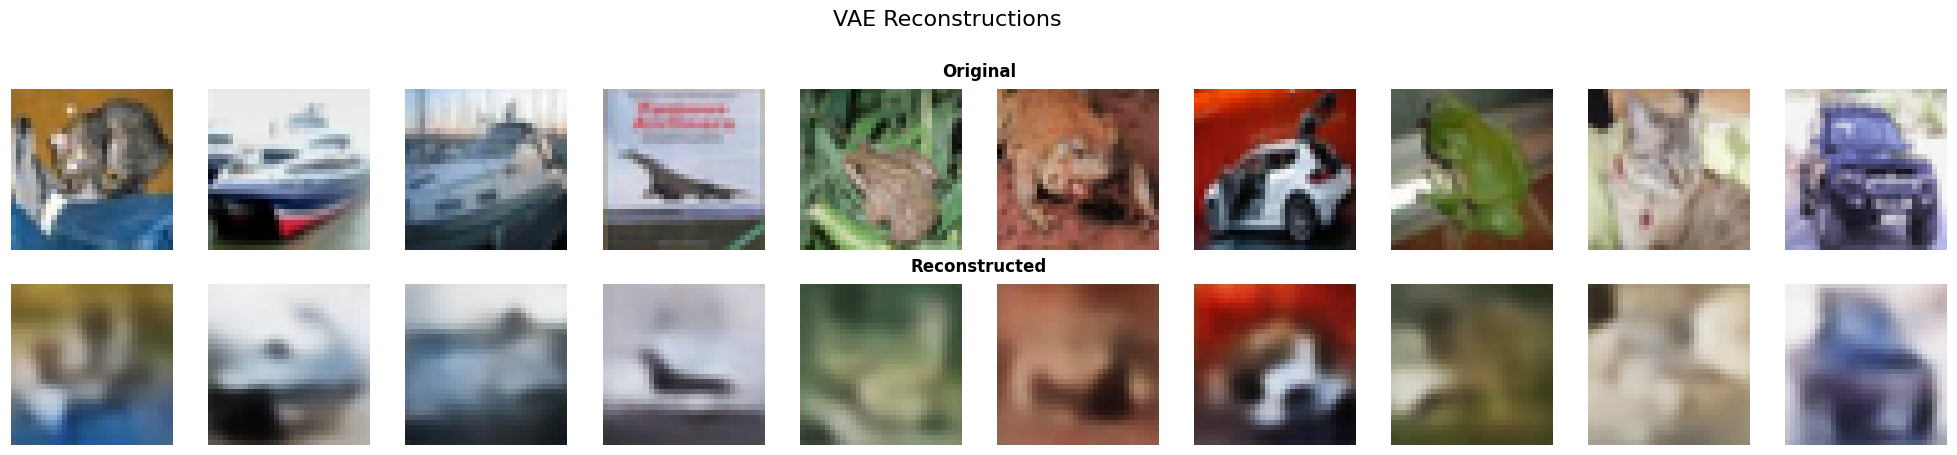

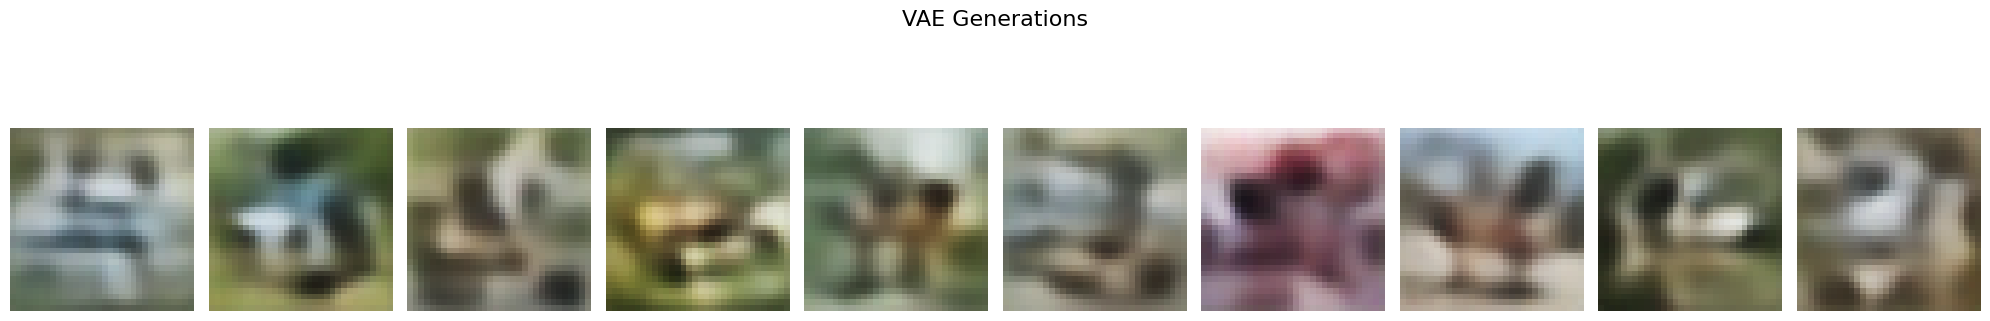

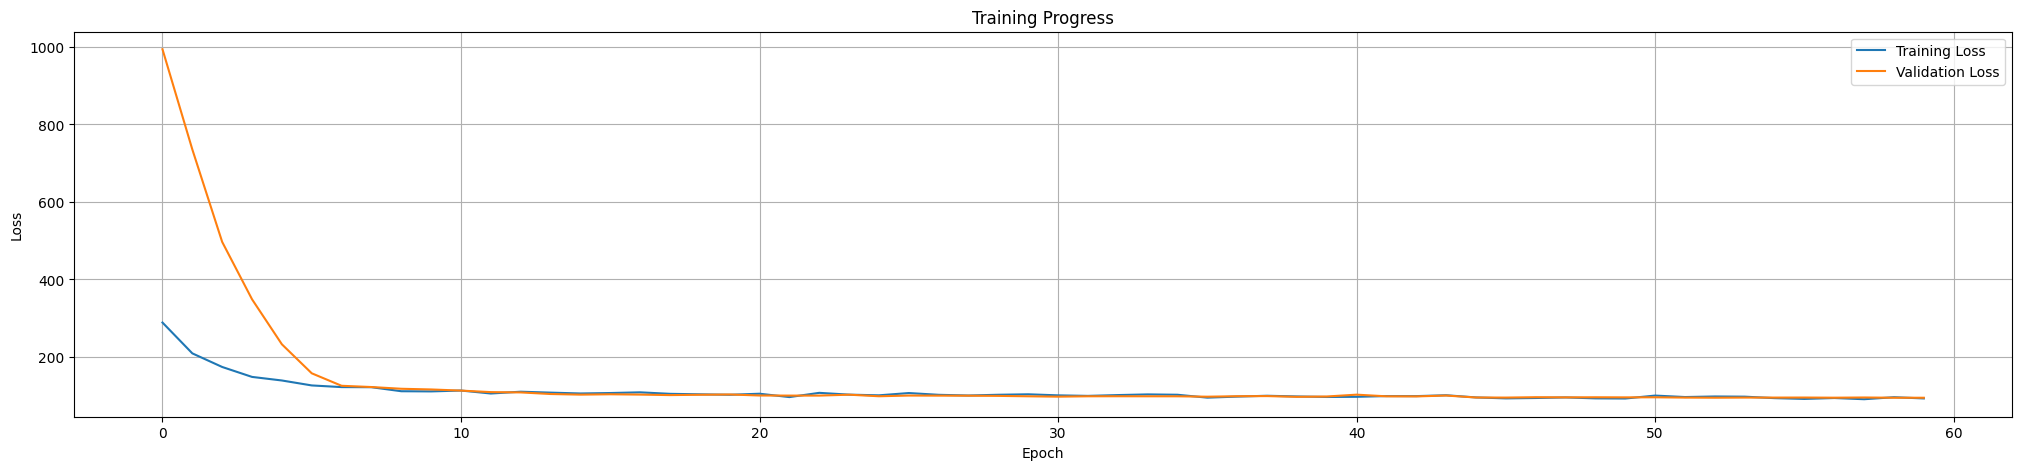

Final training loss:   92.8702
Final validation loss: 94.6674


In [ ]:
# Function to convert [-1, 1] images to [0, 1] for display
def tanh_display(img):
    return (np.clip(img, -1, 1) + 1) / 2

# Reconstruct 10 test images
test_samples  = x_test[:10]
reconstructed = vae.predict(test_samples, verbose=0)

# Show originals vs reconstructions
fig = plt.figure(figsize=(25, 5))
gs = fig.add_gridspec(4, 10, height_ratios=[0.15, 1, 0.15, 1], hspace=0.05)

# Label rows
for label, row in [('Original', 0), ('Reconstructed', 2)]:
    ax = fig.add_subplot(gs[row, :])
    ax.text(0.5, 0.5, label, ha='center', va='center', fontsize=12, fontweight='bold')
    ax.axis('off')

# Image rows
for i in range(10):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(tanh_display(test_samples[i]))
    ax.axis('off')

    ax = fig.add_subplot(gs[3, i])
    ax.imshow(tanh_display(reconstructed[i]))
    ax.axis('off')

plt.suptitle('VAE Reconstructions', fontsize=16)
plt.tight_layout()
plt.show()

# Generate 10 new images
n_samples = 10
random_latent = np.random.normal(size=(n_samples, LATENT_DIM))
generated = decoder.predict(random_latent, verbose=0)

fig, axes = plt.subplots(1, 10, figsize=(20, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(tanh_display(generated[i]))
    ax.axis('off')

plt.suptitle('VAE Generations', fontsize=16)
plt.tight_layout()
plt.show()

# Training loss curve
plt.figure(figsize=(25, 5))
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final training loss:   {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")

In [ ]:
vae.summary(expand_nested=True)

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ ((None, 64), (None,    │       360,672 │
│                                 │ 64), (None, 64))       │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer (InputLayer)   │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d (Conv2D)            │ (None, 16, 16, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization        │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_1 (Conv2D)          │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_1      │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_2 (Conv2D)          │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_2      │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_3 (Conv2D)          │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_3      │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ flatten (Flatten)          │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dropout (Dropout)          │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ z_mean (Dense)             │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ z_log_var (Dense)          │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ sampling (Sampling)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 32, 32, 3)      │       378,979 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer_1 (InputLayer) │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense (Dense)              │ (None, 2048)           │       133,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ reshape (Reshape)          │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_transpose           │ (None, 4, 4, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_4      │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,217,035 (8.46 MB)

 Trainable params: 738,691 (2.82 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 1,477,384 (5.64 MB)